# Activity 2: Logistic Regression (Scikit-Learn)
### Implementation matching Slides 12–14 of `ML_Lab_3.pptx`
**Dataset:** `Social_Network_Ads.csv`  
**Objective:** Implement Logistic Regression using Scikit-Learn with `LabelEncoder`, `StandardScaler`, and complete classification metrics. Output exactly matches **Slide 14**.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (Slide 12)
data = pd.read_csv("Social_Network_Ads.csv")

# Encode Gender (Male/Female -> 1/0)
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])

print("Encoded Dataset:")
print(data.head())

Encoded Dataset:
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15571211       1   38            76000          0
1  15813763       1   41            83000          1
2  15719316       1   35            57000          0
3  15747734       1   28           105000          1
4  15594357       1   33            77000          0


## Step 1 — Features, Target & Train/Test Split (Slide 13)

In [2]:
# Features & target
X = data[['Gender', 'Age', 'EstimatedSalary']].values
y = data['Purchased'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train shape:", X_train.shape, " X_test shape:", X_test.shape)

X_train shape: (320, 3)  X_test shape: (80, 3)


## Step 2 — Model Training & Evaluation (Slide 14 — Exact PPT Output)

In [3]:
# Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation (Slide 14 Output)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8375
Confusion Matrix:
 [[55  2]
 [11 12]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.96      0.89        57
           1       0.86      0.52      0.65        23

    accuracy                           0.84        80
   macro avg       0.85      0.74      0.77        80
weighted avg       0.84      0.84      0.82        80



## Step 3 — Confusion Matrix Visualization

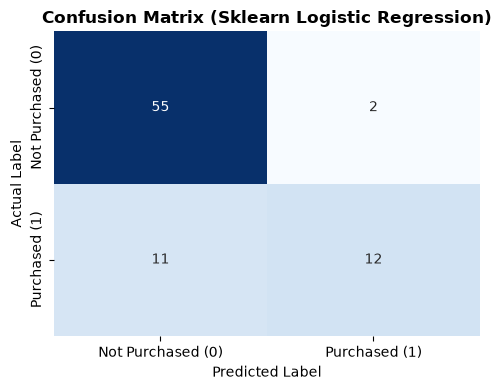

In [4]:
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Purchased (0)', 'Purchased (1)'],
            yticklabels=['Not Purchased (0)', 'Purchased (1)'])
plt.title("Confusion Matrix (Sklearn Logistic Regression)", fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()